# Predizione di disoccupazione e occupazione in Italia

Analisi territoriale e temporale su dati ISTAT regionali, con il PIL regionale come fattore esterno.

La struttura segue l'idea del progetto di riferimento: prima costruzione e controllo dei dati, poi EDA temporale/territoriale, e nelle prossime fasi modelli di regressione/classificazione per prevedere disoccupazione e occupazione.

## Data & Methodology Overview

**Fonti dati**
- Tasso di disoccupazione per territorio, sesso, eta e anno.
- Occupati in migliaia per territorio, sesso, eta e anno.
- Prodotto interno lordo ai prezzi di mercato per territorio e anno.
- NEET come variabile di contesto per il mercato del lavoro giovanile.

**Scelte iniziali**
- Focus su regioni e province autonome, escludendo Italia, macro-aree e province.
- Classe principale: `Totale`, `15-64 anni`, coerente con l'eta lavorativa standard.
- Merge su `REF_AREA`, `Territorio`, `year`.
- Dopo il filtro sulle sole regioni, i dataset lavoro coprono il periodo 2018-2025; il PIL arriva al 2024. Il campione utile per i modelli con PIL e quindi 2018-2024.

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src import utils

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Controllo dei dataset grezzi

Prima vista su dimensioni, copertura temporale, territori disponibili e valori mancanti. La seconda tabella e quella piu importante per il progetto, perche mostra la copertura dopo il filtro su regioni e province autonome.

In [2]:
overview = utils.dataset_overview()
overview

,dataset,rows,columns,year_min,year_max,territories,missing_obs
0,unemployment,10752,14,2004,2025,28,0
1,employment,6468,12,2004,2025,28,0
2,gdp,3528,32,1995,2024,139,0
3,neet_rate,672,14,2018,2025,28,0
4,neet_count,896,12,2018,2025,28,0


In [3]:
regional_coverage = utils.regional_coverage_overview()
regional_coverage

,dataset,rows_regional,territories,year_min,year_max,years,missing_obs
0,unemployment,6552,21,2018,2025,8,0
1,employment,3528,21,2018,2025,8,0
2,gdp,630,21,1995,2024,30,0
3,neet_rate,504,21,2018,2025,8,0
4,neet_count,672,21,2018,2025,8,0


In [4]:
raw_unemployment = utils.read_istat_csv(utils.RAW_FILES["unemployment"])
regions = (
    utils.filter_regions(raw_unemployment)[["REF_AREA", "Territorio"]]
    .drop_duplicates()
    .sort_values("REF_AREA")
)
regions

,REF_AREA,Territorio
1944,ITC1,Piemonte
2256,ITC2,Valle d'Aosta
2568,ITC3,Liguria
2880,ITC4,Lombardia
4152,ITD1,Bolzano
4464,ITD2,Trento
4776,ITD3,Veneto
5088,ITD4,Friuli-Venezia Giulia
5400,ITD5,Emilia-Romagna
6360,ITE1,Toscana


## 2. Preprocessing e costruzione del panel

Qui uniamo i dataset principali in un panel regione-anno. In questa prima fase il panel serve per EDA; nelle prossime fasi diventera la base per feature engineering e modelli predittivi.

In [5]:
panel = utils.build_labour_panel(include_neet=True)
panel.head()

,REF_AREA,Territorio,year,unemployment_rate,employed_thousands,gdp_million_eur,gdp_yoy_pct,gdp_lag1,neet_rate,log_gdp,gdp_per_employed_k_eur,unemployment_rate_lag1,employed_thousands_lag1
0,ITC1,Piemonte,2018,8.362247,1765.876,135216.6,1.953774,132625.4,17.606570,11.814633,76.571968,NaN,NaN
1,ITC1,Piemonte,2019,7.786975,1758.282,135773.8,0.412080,135216.6,16.514095,11.818746,77.219581,8.362247,1765.876
2,ITC1,Piemonte,2020,7.808230,1697.705,124757.0,-8.114084,135773.8,20.014564,11.734123,73.485676,7.786975,1758.282
3,ITC1,Piemonte,2021,7.473577,1708.233,137614.9,10.306356,124757.0,19.194039,11.832214,80.559795,7.808230,1697.705
4,ITC1,Piemonte,2022,6.561637,1731.354,146819.8,6.688883,137614.9,15.351761,11.896961,84.800566,7.473577,1708.233


In [6]:
panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   REF_AREA                 168 non-null    str    
 1   Territorio               168 non-null    str    
 2   year                     168 non-null    int64  
 3   unemployment_rate        168 non-null    float64
 4   employed_thousands       168 non-null    float64
 5   gdp_million_eur          147 non-null    float64
 6   gdp_yoy_pct              147 non-null    float64
 7   gdp_lag1                 147 non-null    float64
 8   neet_rate                168 non-null    float64
 9   log_gdp                  147 non-null    float64
 10  gdp_per_employed_k_eur   147 non-null    float64
 11  unemployment_rate_lag1   147 non-null    float64
 12  employed_thousands_lag1  147 non-null    float64
dtypes: float64(10), int64(1), str(2)
memory usage: 17.2 KB


In [7]:
utils.missing_summary(panel)

,missing,missing_pct
gdp_million_eur,21,12.5
gdp_yoy_pct,21,12.5
gdp_lag1,21,12.5
log_gdp,21,12.5
gdp_per_employed_k_eur,21,12.5
unemployment_rate_lag1,21,12.5
employed_thousands_lag1,21,12.5


In [8]:
processed_path = utils.save_processed_panel()
processed_path

PosixPath('/Users/simon/Documents/big data prog/data/processed/labour_panel.csv')

## 3. Copertura temporale dopo il merge

Il grafico di copertura serve soprattutto a evidenziare un limite importante: il 2025 e disponibile per disoccupazione, occupati e NEET, ma non per il PIL. Per evitare imputazioni arbitrarie, la parte modellistica con PIL usera il periodo completo 2018-2024.

In [9]:
coverage = panel.groupby("year").agg(
    regions=("REF_AREA", "nunique"),
    unemployment_available=("unemployment_rate", lambda s: s.notna().sum()),
    employment_available=("employed_thousands", lambda s: s.notna().sum()),
    gdp_available=("gdp_million_eur", lambda s: s.notna().sum()),
    neet_available=("neet_rate", lambda s: s.notna().sum()),
).reset_index()
coverage["complete_with_gdp"] = coverage[["unemployment_available", "employment_available", "gdp_available"]].min(axis=1)
coverage

,year,regions,unemployment_available,employment_available,gdp_available,neet_available,complete_with_gdp
0,2018,21,21,21,21,21,21
1,2019,21,21,21,21,21,21
2,2020,21,21,21,21,21,21
3,2021,21,21,21,21,21,21
4,2022,21,21,21,21,21,21
5,2023,21,21,21,21,21,21
6,2024,21,21,21,21,21,21
7,2025,21,21,21,0,21,0


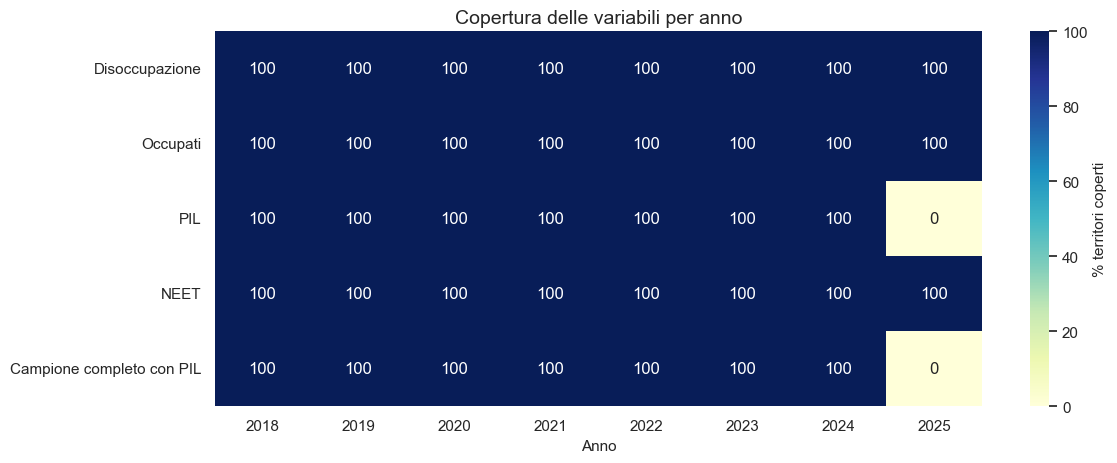

In [10]:
availability = coverage.set_index("year")[
    ["unemployment_available", "employment_available", "gdp_available", "neet_available", "complete_with_gdp"]
]
availability_pct = availability.div(coverage.set_index("year")["regions"], axis=0) * 100
availability_pct = availability_pct.rename(
    columns={
        "unemployment_available": "Disoccupazione",
        "employment_available": "Occupati",
        "gdp_available": "PIL",
        "neet_available": "NEET",
        "complete_with_gdp": "Campione completo con PIL",
    }
)

fig, ax = plt.subplots(figsize=(12, 4.8))
sns.heatmap(
    availability_pct.T,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    cbar_kws={"label": "% territori coperti"},
    ax=ax,
)
ax.set_title("Copertura delle variabili per anno")
ax.set_xlabel("Anno")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "coverage_by_year.png", dpi=150)
plt.show()

In [11]:
model_panel = utils.modelling_sample(panel)
print(
    f"Campione per modelli con PIL: {model_panel.shape[0]} osservazioni, "
    f"{model_panel['REF_AREA'].nunique()} territori, anni {model_panel['year'].min()}-{model_panel['year'].max()}"
)

Campione per modelli con PIL: 147 osservazioni, 21 territori, anni 2018-2024


## 4. EDA: evoluzione temporale del mercato del lavoro

Media semplice tra regioni e province autonome. Non e una media pesata per popolazione, ma aiuta a leggere l'andamento territoriale medio.

In [12]:
regional_mean = panel.groupby("year", as_index=False).agg(
    unemployment_rate=("unemployment_rate", "mean"),
    employed_thousands=("employed_thousands", "mean"),
    gdp_million_eur=("gdp_million_eur", "mean"),
    gdp_per_employed_k_eur=("gdp_per_employed_k_eur", "mean"),
    neet_rate=("neet_rate", "mean"),
)
regional_mean.tail()

,year,unemployment_rate,employed_thousands,gdp_million_eur,gdp_per_employed_k_eur,neet_rate
3,2021,9.598906,1040.437905,87662.404762,80.451652,21.809646
4,2022,8.262255,1067.261000,95109.000000,85.364481,17.829165
5,2023,7.736809,1087.378524,101987.652381,90.159103,14.933370
6,2024,6.606283,1102.382238,104703.257143,91.102741,14.435229
7,2025,6.171204,1107.198143,NaN,NaN,12.485940


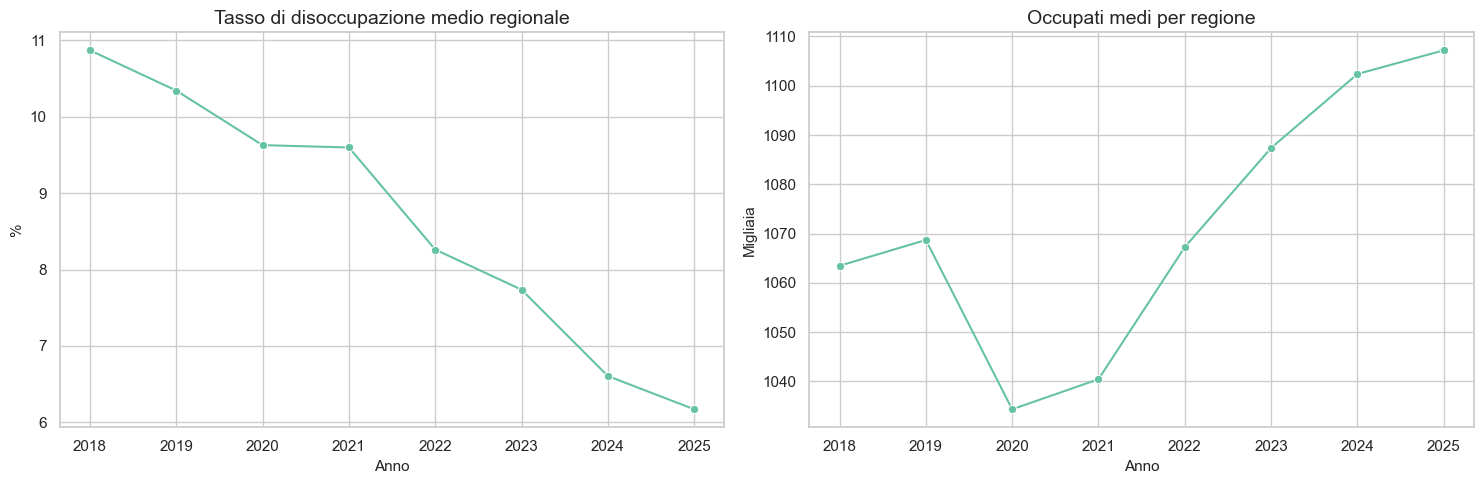

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=regional_mean, x="year", y="unemployment_rate", marker="o", ax=axes[0])
axes[0].set_title("Tasso di disoccupazione medio regionale")
axes[0].set_xlabel("Anno")
axes[0].set_ylabel("%")

sns.lineplot(data=regional_mean, x="year", y="employed_thousands", marker="o", ax=axes[1])
axes[1].set_title("Occupati medi per regione")
axes[1].set_xlabel("Anno")
axes[1].set_ylabel("Migliaia")

plt.tight_layout()
plt.savefig(FIG_DIR / "labour_trends.png", dpi=150)
plt.show()

## 5. EDA: differenze territoriali nell'ultimo anno completo con PIL

Il 2024 e l'ultimo anno in cui il PIL e disponibile insieme ai target del lavoro.

In [14]:
latest_model_year = int(model_panel["year"].max())
latest = model_panel.query("year == @latest_model_year").copy()
latest_model_year, latest.shape

(2024, (21, 13))

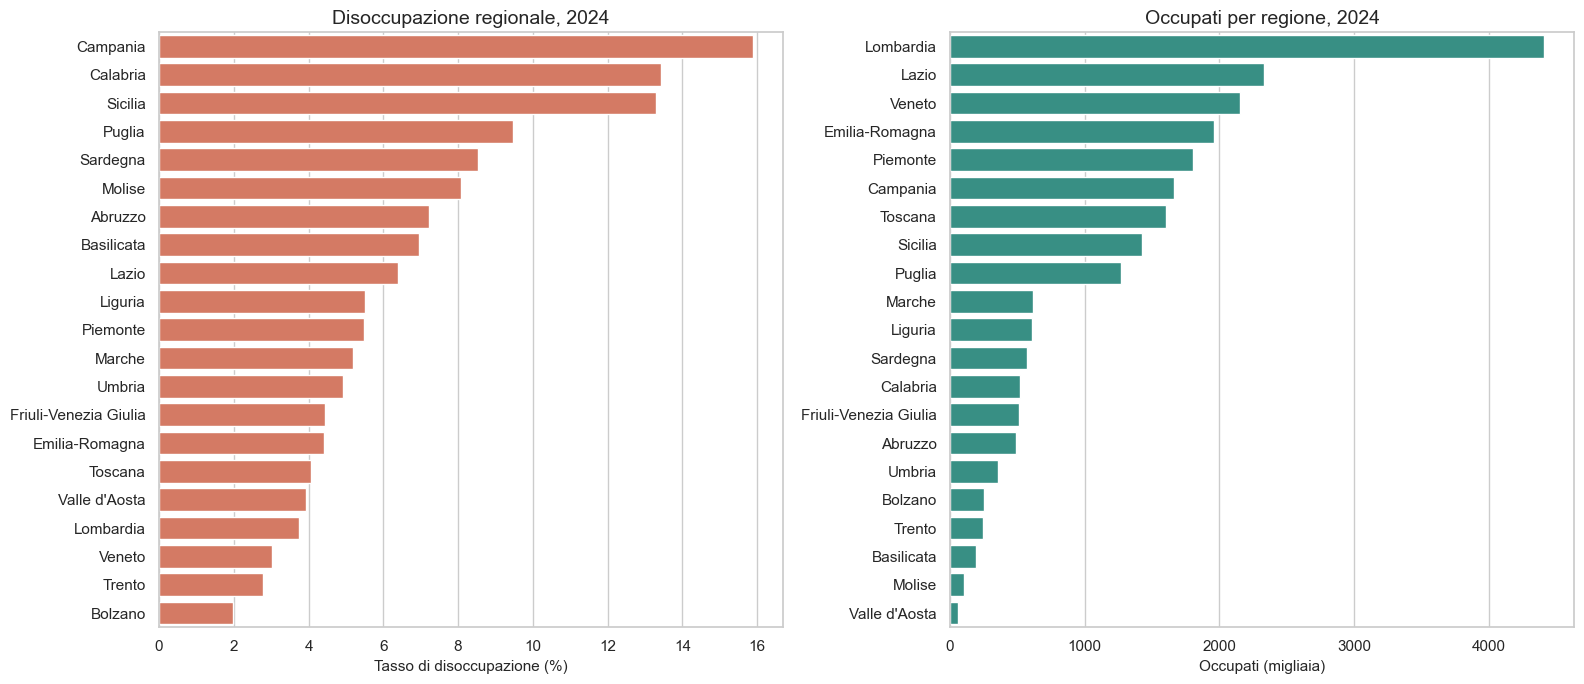

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

unemp_sorted = latest.sort_values("unemployment_rate", ascending=False)
sns.barplot(data=unemp_sorted, x="unemployment_rate", y="Territorio", ax=axes[0], color="#E76F51")
axes[0].set_title(f"Disoccupazione regionale, {latest_model_year}")
axes[0].set_xlabel("Tasso di disoccupazione (%)")
axes[0].set_ylabel("")

emp_sorted = latest.sort_values("employed_thousands", ascending=False)
sns.barplot(data=emp_sorted, x="employed_thousands", y="Territorio", ax=axes[1], color="#2A9D8F")
axes[1].set_title(f"Occupati per regione, {latest_model_year}")
axes[1].set_xlabel("Occupati (migliaia)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "regional_rankings_latest_year.png", dpi=150)
plt.show()

### Variazione 2018-2024

Oltre alla classifica dell'ultimo anno, guardiamo anche come sono cambiate le regioni nel periodo completo con PIL. Questo e piu informativo per un progetto predittivo rispetto a una fotografia singola.

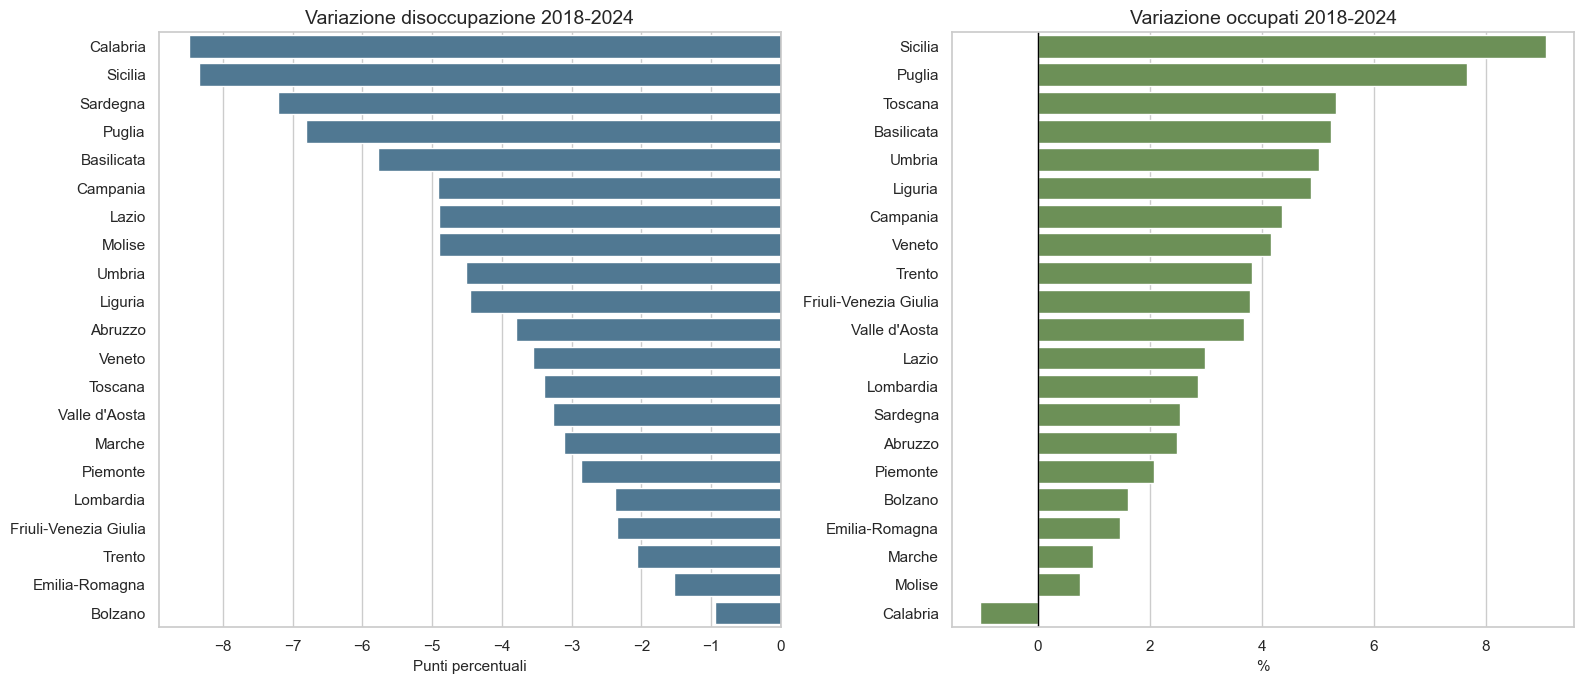

,Territorio,unemployment_change_pp,employment_change_pct
3,Calabria,-8.489817,-1.022632
15,Sicilia,-8.342507,9.072504
14,Sardegna,-7.212682,2.541571
13,Puglia,-6.801750,7.673820
1,Basilicata,-5.774968,5.236906


In [16]:
start_year = int(model_panel["year"].min())
end_year = int(model_panel["year"].max())
wide = model_panel.pivot(index="Territorio", columns="year", values=["unemployment_rate", "employed_thousands"])
change = pd.DataFrame(
    {
        "unemployment_change_pp": wide["unemployment_rate"][end_year] - wide["unemployment_rate"][start_year],
        "employment_change_pct": (wide["employed_thousands"][end_year] / wide["employed_thousands"][start_year] - 1) * 100,
    }
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(
    data=change.sort_values("unemployment_change_pp"),
    x="unemployment_change_pp",
    y="Territorio",
    ax=axes[0],
    color="#457B9D",
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(f"Variazione disoccupazione {start_year}-{end_year}")
axes[0].set_xlabel("Punti percentuali")
axes[0].set_ylabel("")

sns.barplot(
    data=change.sort_values("employment_change_pct", ascending=False),
    x="employment_change_pct",
    y="Territorio",
    ax=axes[1],
    color="#6A994E",
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"Variazione occupati {start_year}-{end_year}")
axes[1].set_xlabel("%")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "regional_changes_2018_2024.png", dpi=150)
plt.show()

change.sort_values("unemployment_change_pp").head()

## 6. EDA: relazione tra PIL e variabili target

Questa sezione anticipa il ruolo del PIL come fattore esterno. Il PIL assoluto e utile per predire il numero di occupati, ma per il tasso di disoccupazione puo essere meno interpretabile perche riflette anche la dimensione della regione. Per questo affianchiamo `log_gdp` e `gdp_per_employed_k_eur`.

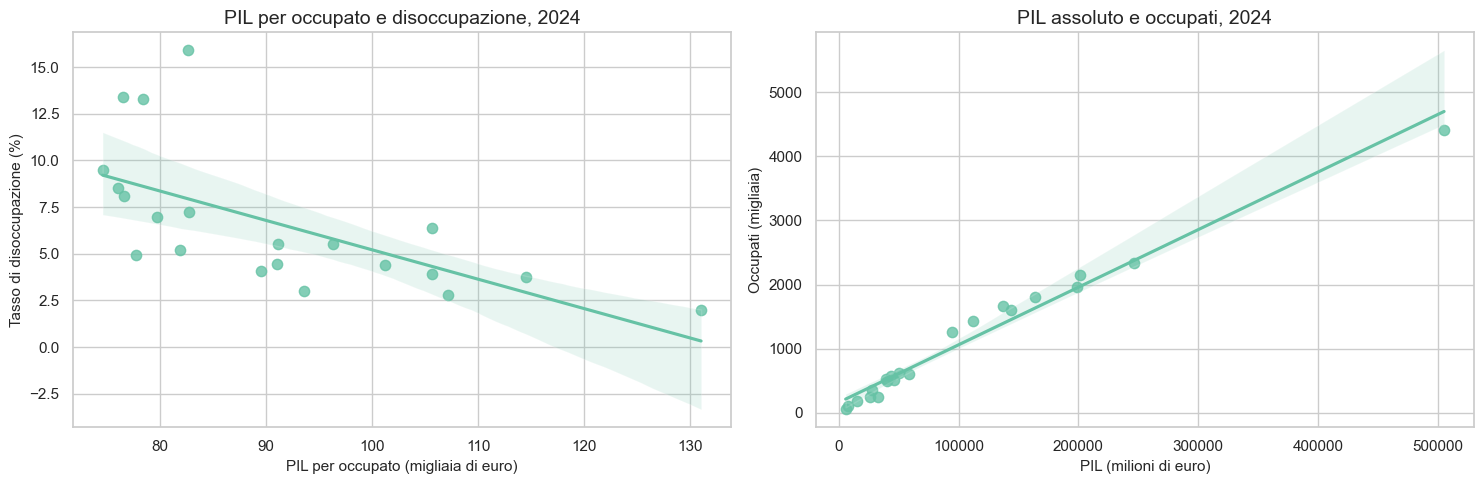

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(data=latest, x="gdp_per_employed_k_eur", y="unemployment_rate", ax=axes[0], scatter_kws={"s": 55})
axes[0].set_title(f"PIL per occupato e disoccupazione, {latest_model_year}")
axes[0].set_xlabel("PIL per occupato (migliaia di euro)")
axes[0].set_ylabel("Tasso di disoccupazione (%)")

sns.regplot(data=latest, x="gdp_million_eur", y="employed_thousands", ax=axes[1], scatter_kws={"s": 55})
axes[1].set_title(f"PIL assoluto e occupati, {latest_model_year}")
axes[1].set_xlabel("PIL (milioni di euro)")
axes[1].set_ylabel("Occupati (migliaia)")

plt.tight_layout()
plt.savefig(FIG_DIR / "gdp_vs_targets_latest_year.png", dpi=150)
plt.show()

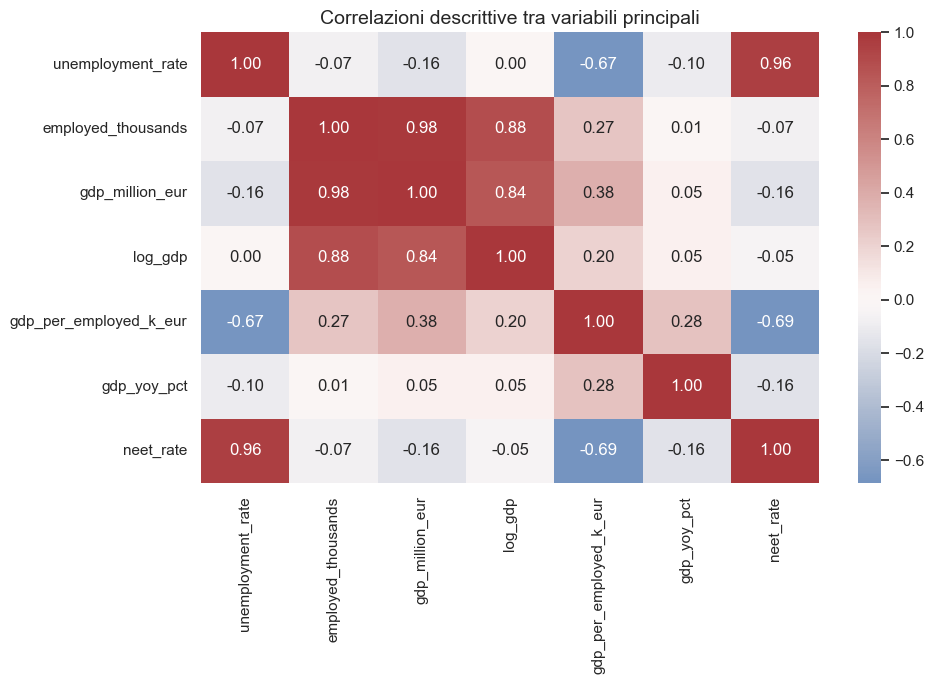

,unemployment_rate,employed_thousands,gdp_million_eur,log_gdp,gdp_per_employed_k_eur,gdp_yoy_pct,neet_rate
unemployment_rate,1.000000,-0.070459,-0.159910,0.001128,-0.671302,-0.104048,0.955521
employed_thousands,-0.070459,1.000000,0.984388,0.883472,0.273714,0.011602,-0.070373
gdp_million_eur,-0.159910,0.984388,1.000000,0.835348,0.375956,0.051761,-0.159493
log_gdp,0.001128,0.883472,0.835348,1.000000,0.203356,0.051007,-0.049003
gdp_per_employed_k_eur,-0.671302,0.273714,0.375956,0.203356,1.000000,0.283489,-0.686485
gdp_yoy_pct,-0.104048,0.011602,0.051761,0.051007,0.283489,1.000000,-0.155045
neet_rate,0.955521,-0.070373,-0.159493,-0.049003,-0.686485,-0.155045,1.000000


In [18]:
corr_cols = [
    "unemployment_rate",
    "employed_thousands",
    "gdp_million_eur",
    "log_gdp",
    "gdp_per_employed_k_eur",
    "gdp_yoy_pct",
    "neet_rate",
]
corr = model_panel[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="vlag", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlazioni descrittive tra variabili principali")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

corr

## 7. EDA: focus NEET come contesto del mercato del lavoro

Il NEET copre tutto il periodo 2018-2025, ma per i modelli con PIL useremo 2018-2024. La sua relazione con la disoccupazione e descrittivamente forte, quindi va gestita con attenzione per evitare ridondanza informativa.

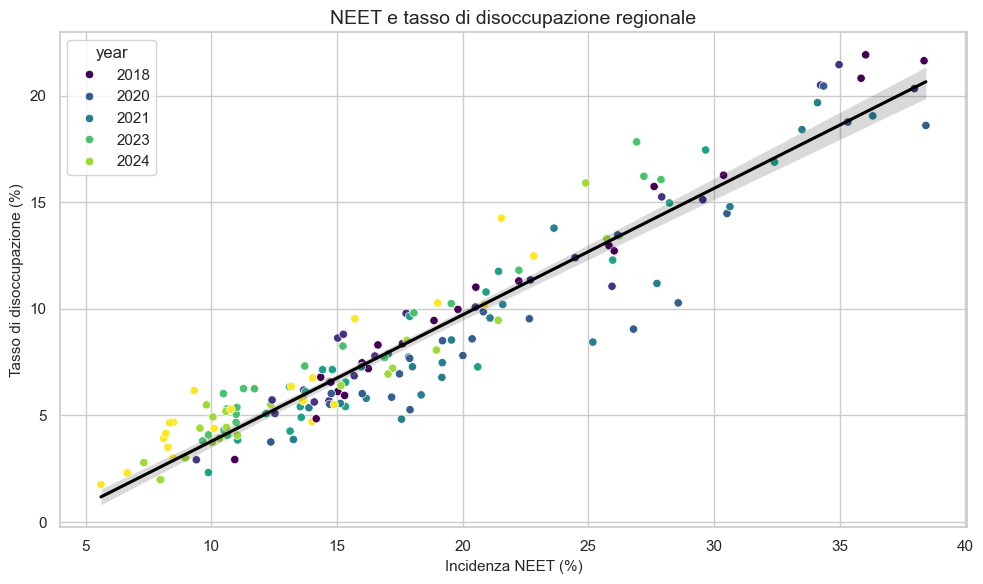

In [19]:
neet_panel = panel.dropna(subset=["neet_rate", "unemployment_rate"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=neet_panel,
    x="neet_rate",
    y="unemployment_rate",
    hue="year",
    palette="viridis",
    ax=ax,
)
sns.regplot(data=neet_panel, x="neet_rate", y="unemployment_rate", scatter=False, color="black", ax=ax)
ax.set_title("NEET e tasso di disoccupazione regionale")
ax.set_xlabel("Incidenza NEET (%)")
ax.set_ylabel("Tasso di disoccupazione (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "neet_vs_unemployment.png", dpi=150)
plt.show()

## Prime evidenze e prossimi passi

**Cosa abbiamo pronto**
- Dataset regionali normalizzati e salvati come `data/processed/labour_panel.csv`.
- Target principali: `unemployment_rate` e `employed_thousands`.
- Campione per modelli con PIL: 147 osservazioni, 21 territori, 2018-2024.
- Fattori esterni dal PIL: `gdp_million_eur`, `log_gdp`, `gdp_yoy_pct`, `gdp_per_employed_k_eur`.
- Variabile di contesto opzionale: `neet_rate`.

**Prossima fase, quando confermi**
- Feature engineering piu completo: lag dei target, variazioni percentuali, dummy regionali, macro-area.
- Modelli baseline: regressione lineare/Ridge/Random Forest per disoccupazione e occupati.
- Valutazione temporale train-test, evitando split casuale puro su serie storiche.
- Classificazione di regioni critiche, simile al PDF, usando soglia mediana/nazionale.